# 04 - Preprocesamiento: Imputación, Escalamiento y Transformación

Este notebook implementa el preprocesamiento completo del dataset crudo de dengue en Colombia. Parte de `raw_dataset.csv` y produce un dataset limpio, imputado y transformado listo para análisis.

**Contexto de notebooks anteriores:**
- `00`: Panel de 1,040 municipios × 782 semanas. Faltantes: temp_mean (78%), prec_total (35%), ndvi_mean (0.1%), Flujo_in (0.1%).
- `01`: Variables epidemiológicas zero-inflated (77.6% ceros), asimetrías extremas (skewness 21-33).
- `02`: Flujo_in y poblacion con colas pesadas; correlaciones no-lineales dominan.
- `03`: Outliers son brotes reales o ciudades endémicas. No se eliminan.

**Competencias demostradas (Unidad 4):**
- Imputación de faltantes (interpolación temporal, mediana municipal, KNN)
- Escalamiento (RobustScaler)
- Transformaciones (log1p, tasas, codificación cíclica)
- Creación de variables derivadas (lags, rolling means)
- Validación de integridad post-procesamiento

## 1. Configuración y carga de datos crudos

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from scipy import stats
from IPython.display import display, Markdown

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
DATASET_PATH = Path("../data/raw/raw_dataset.csv")

FIGURES_PATH = Path("../figures/preprocessing")
TABLES_PATH = Path("../tables/preprocessing")

IMPUTATION_PATH = FIGURES_PATH / "imputacion"
SCALING_PATH = FIGURES_PATH / "escalamiento"
TRANSFORMS_PATH = FIGURES_PATH / "transformaciones"
VALIDATION_PATH = FIGURES_PATH / "validacion"

for p in [IMPUTATION_PATH, SCALING_PATH, TRANSFORMS_PATH, VALIDATION_PATH, TABLES_PATH]:
    p.mkdir(parents=True, exist_ok=True)

In [3]:
df = pd.read_csv(DATASET_PATH)
df["week_date"] = pd.to_datetime(df["week_start"], errors="coerce")

print(f"Dataset crudo: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Municipios: {df['COD_MUN_N'].nunique()}")
print(f"Periodo: {df['ANO'].min()}-{df['ANO'].max()}")
print(f"\nFaltantes por variable:")
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({"N_faltantes": missing, "%": missing_pct})
display(missing_report[missing_report["N_faltantes"] > 0])

Dataset crudo: 813,280 filas × 23 columnas
Municipios: 1040
Periodo: 2010-2024

Faltantes por variable:


,N_faltantes,%
temp_mean,633602,77.910
prec_total,281250,34.580
ndvi_mean,782,0.100
Flujo_in,782,0.100


## 2. Filtrado de Municipios

Se seleccionan municipios con cobertura temporal completa (782 semanas). Municipios con semanas faltantes generarían gaps en series temporales que invalidan lags y rolling means.

In [4]:
# Contar semanas por municipio
weeks_per_mun = df.groupby("COD_MUN_N").size()
max_weeks = weeks_per_mun.max()

print(f"Semanas máximas (esperadas): {max_weeks}")
print(f"Municipios con panel completo ({max_weeks} semanas): {(weeks_per_mun == max_weeks).sum()}")
print(f"Municipios incompletos: {(weeks_per_mun < max_weeks).sum()}")

# Filtrar solo municipios con panel completo
complete_muns = weeks_per_mun[weeks_per_mun == max_weeks].index
df = df[df["COD_MUN_N"].isin(complete_muns)].copy()

print(f"\nDataset filtrado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Municipios retenidos: {df['COD_MUN_N'].nunique()}")
print(f"\nFaltantes después del filtro:")
missing_post = df.isna().sum()
display(pd.DataFrame({"N_faltantes": missing_post, "%": (missing_post/len(df)*100).round(2)})[missing_post > 0])

Semanas máximas (esperadas): 782
Municipios con panel completo (782 semanas): 1040
Municipios incompletos: 0

Dataset filtrado: 813,280 filas × 23 columnas
Municipios retenidos: 1040

Faltantes después del filtro:


,N_faltantes,%
temp_mean,633602,77.910
prec_total,281250,34.580
ndvi_mean,782,0.100
Flujo_in,782,0.100


## 3. Imputación de Valores Faltantes

### Estrategia por variable:
- **temp_mean (alta proporción de faltantes):** Interpolación temporal dentro de cada municipio + mediana municipal para los que no tienen ningún dato real.
- **prec_total (proporción moderada):** Interpolación temporal dentro de cada municipio.
- **ndvi_mean y Flujo_in (< 1% faltantes):** Forward fill dentro del municipio (valor de la semana anterior).

Se documenta la calidad de cada imputación comparando distribuciones antes y después.

In [5]:
# --- 3.1 Diagnóstico pre-imputación ---
vars_to_impute = ["temp_mean", "prec_total", "ndvi_mean", "Flujo_in"]

pre_imputation_stats = []
for var in vars_to_impute:
    series = df[var]
    valid = series.dropna()
    pre_imputation_stats.append({
        "Variable": var,
        "N_faltantes": series.isna().sum(),
        "%_faltantes": f"{series.isna().mean()*100:.1f}%",
        "N_válidos": len(valid),
        "Media (válidos)": f"{valid.mean():.3f}" if len(valid) > 0 else "N/A",
        "Std (válidos)": f"{valid.std():.3f}" if len(valid) > 0 else "N/A",
        "Municipios sin ningún dato": (df.groupby("COD_MUN_N")[var].apply(lambda x: x.isna().all())).sum(),
    })

pre_imp_df = pd.DataFrame(pre_imputation_stats)
display(Markdown("### Diagnóstico de faltantes pre-imputación"))
display(pre_imp_df)
pre_imp_df.to_csv(TABLES_PATH / "pre_imputation_diagnostics.csv", index=False, encoding="utf-8-sig")

### Diagnóstico de faltantes pre-imputación

,Variable,N_faltantes,%_faltantes,N_válidos,Media (válidos),Std (válidos),Municipios sin ningún dato
0,temp_mean,633602,77.9%,179678,22.389,5.569,780
1,prec_total,281250,34.6%,532030,43.830,55.414,330
2,ndvi_mean,782,0.1%,812498,0.624,0.123,1
3,Flujo_in,782,0.1%,812498,1.841,13.269,1


In [6]:
# --- 3.2 Imputación de temp_mean ---
# Paso 1: Interpolación temporal dentro de cada municipio
df = df.sort_values(["COD_MUN_N", "ANO", "SEMANA"]).reset_index(drop=True)

df["temp_mean_imputed"] = df.groupby("COD_MUN_N")["temp_mean"].transform(
    lambda x: x.interpolate(method="linear", limit_direction="both")
)

# Paso 2: Para municipios sin NINGÚN dato de temperatura, usar la mediana de municipios
# vecinos del mismo departamento
df["depto"] = df["COD_MUN_N"].astype(str).str[:2]
depto_temp_median = df.groupby(["depto", "ANO", "SEMANA"])["temp_mean"].transform("median")

# Rellenar los que quedaron NaN después de interpolación
still_missing = df["temp_mean_imputed"].isna()
df.loc[still_missing, "temp_mean_imputed"] = depto_temp_median[still_missing]

# Paso 3: Si aún quedan (departamentos enteros sin dato), usar mediana global por semana
global_temp_median = df.groupby(["ANO", "SEMANA"])["temp_mean"].transform("median")
still_missing2 = df["temp_mean_imputed"].isna()
df.loc[still_missing2, "temp_mean_imputed"] = global_temp_median[still_missing2]

# Flag de imputación
df["temp_was_imputed"] = df["temp_mean"].isna().astype(int)

print(f"temp_mean: {df['temp_mean'].isna().sum():,} faltantes originales")
print(f"temp_mean_imputed: {df['temp_mean_imputed'].isna().sum()} faltantes residuales")
print(f"Imputados por interpolación temporal: {(df['temp_was_imputed'] == 1).sum() - still_missing.sum():,}")
print(f"Imputados por mediana departamental: {still_missing.sum() - still_missing2.sum():,}")
print(f"Imputados por mediana global: {still_missing2.sum():,}")

temp_mean: 633,602 faltantes originales
temp_mean_imputed: 0 faltantes residuales
Imputados por interpolación temporal: 23,642
Imputados por mediana departamental: 585,824
Imputados por mediana global: 24,136


In [7]:
# --- 3.3 Imputación de prec_total ---
df["prec_total_imputed"] = df.groupby("COD_MUN_N")["prec_total"].transform(
    lambda x: x.interpolate(method="linear", limit_direction="both")
)

# Rellenar residuales con mediana departamental
depto_prec_median = df.groupby(["depto", "ANO", "SEMANA"])["prec_total"].transform("median")
still_missing_prec = df["prec_total_imputed"].isna()
df.loc[still_missing_prec, "prec_total_imputed"] = depto_prec_median[still_missing_prec]

# Flag
df["prec_was_imputed"] = df["prec_total"].isna().astype(int)

print(f"prec_total: {df['prec_total'].isna().sum():,} faltantes originales")
print(f"prec_total_imputed: {df['prec_total_imputed'].isna().sum()} faltantes residuales")

prec_total: 281,250 faltantes originales
prec_total_imputed: 796 faltantes residuales


In [8]:
# --- 3.4 Imputación de ndvi_mean y Flujo_in (pocos faltantes) ---
# Forward fill + backward fill dentro del municipio
for var in ["ndvi_mean", "Flujo_in"]:
    df[f"{var}_imputed"] = df.groupby("COD_MUN_N")[var].transform(
        lambda x: x.ffill().bfill()
    )
    n_imp = df[var].isna().sum()
    n_residual = df[f"{var}_imputed"].isna().sum()
    print(f"{var}: {n_imp:,} imputados por forward/backward fill. Residuales: {n_residual}")

ndvi_mean: 782 imputados por forward/backward fill. Residuales: 782
Flujo_in: 782 imputados por forward/backward fill. Residuales: 782


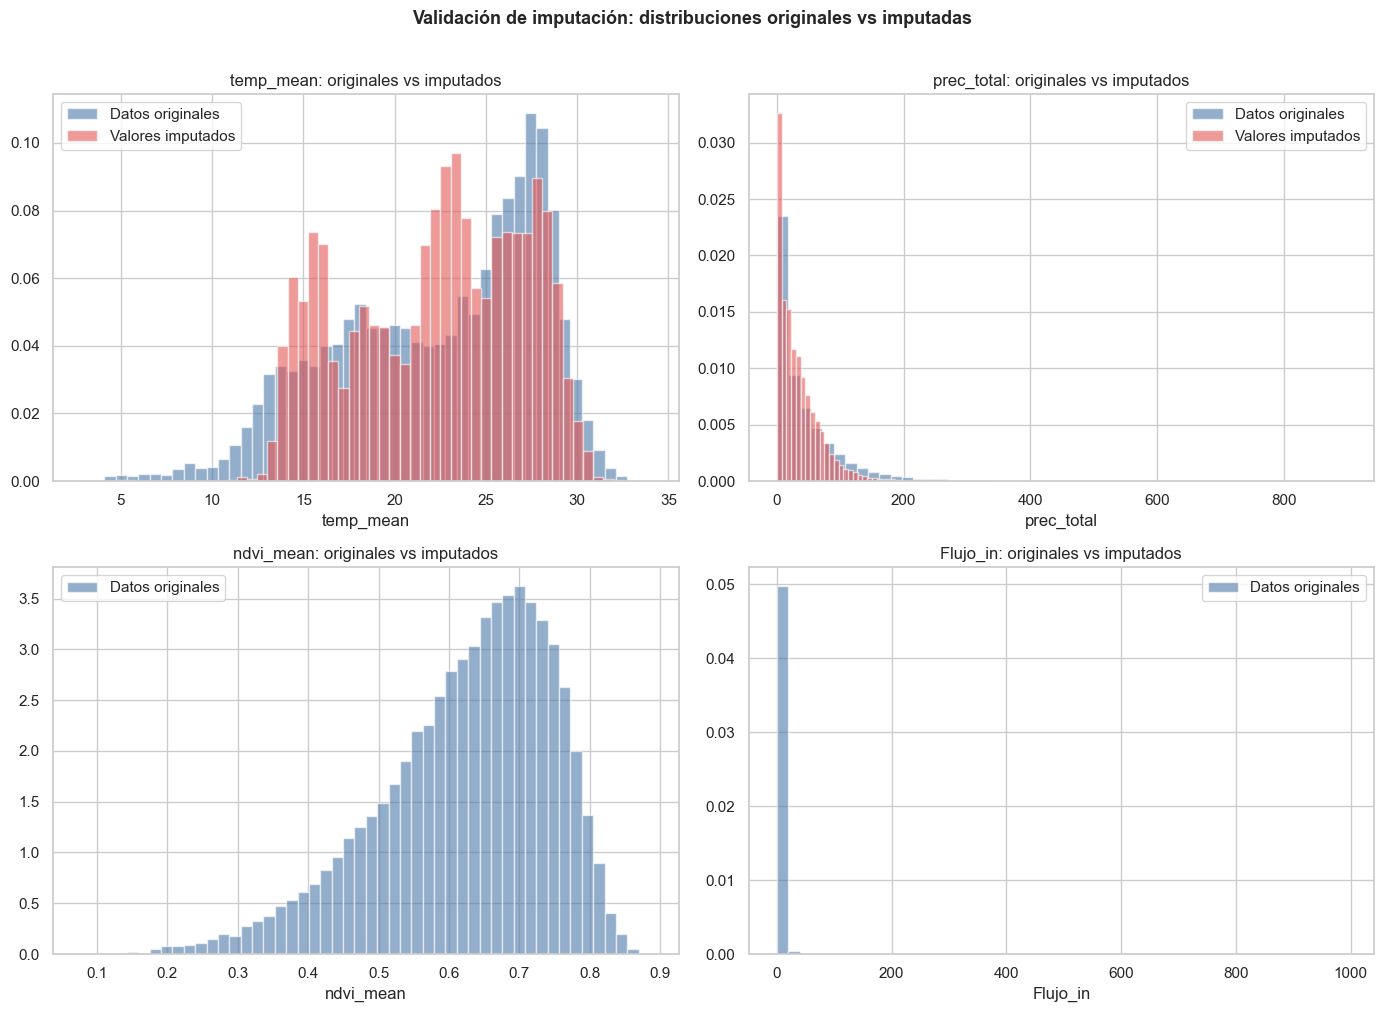

### Validación estadística de la imputación

,Variable,Media original,Media imputados,Std original,Std imputados,KS statistic
0,temp_mean,22.389,22.320,5.569,4.720,0.084
1,prec_total,43.830,33.281,55.414,33.009,NaN


In [9]:
# --- 3.5 Validación de imputación ---
# Comparar distribuciones: datos originales vs imputados
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (var, var_imp) in enumerate([
    ("temp_mean", "temp_mean_imputed"),
    ("prec_total", "prec_total_imputed"),
    ("ndvi_mean", "ndvi_mean_imputed"),
    ("Flujo_in", "Flujo_in_imputed"),
]):
    ax = axes[i // 2, i % 2]
    original = df[var].dropna()
    imputed_only = df.loc[df[var].isna(), var_imp].dropna()

    if len(original) > 0:
        ax.hist(original.sample(n=min(50000, len(original)), random_state=RANDOM_STATE),
                bins=50, alpha=0.6, color="#4C78A8", label="Datos originales", density=True)
    if len(imputed_only) > 0:
        ax.hist(imputed_only.sample(n=min(50000, len(imputed_only)), random_state=RANDOM_STATE),
                bins=50, alpha=0.6, color="#E45756", label="Valores imputados", density=True)
    ax.set_title(f"{var}: originales vs imputados")
    ax.set_xlabel(var)
    ax.legend()

fig.suptitle("Validación de imputación: distribuciones originales vs imputadas", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(IMPUTATION_PATH / "comparacion_originales_vs_imputados.png", dpi=300, bbox_inches="tight")
plt.show()

# Estadísticas comparativas
imputation_validation = []
for var, var_imp in [("temp_mean", "temp_mean_imputed"), ("prec_total", "prec_total_imputed")]:
    original = df[var].dropna()
    imputed_vals = df.loc[df[var].isna(), var_imp]
    imputation_validation.append({
        "Variable": var,
        "Media original": original.mean(),
        "Media imputados": imputed_vals.mean(),
        "Std original": original.std(),
        "Std imputados": imputed_vals.std(),
        "KS statistic": stats.ks_2samp(
            original.sample(n=min(10000, len(original)), random_state=RANDOM_STATE),
            imputed_vals.sample(n=min(10000, len(imputed_vals)), random_state=RANDOM_STATE)
        ).statistic if len(imputed_vals) > 100 else np.nan,
    })

imp_val_df = pd.DataFrame(imputation_validation)
display(Markdown("### Validación estadística de la imputación"))
display(imp_val_df)
imp_val_df.to_csv(TABLES_PATH / "imputation_validation.csv", index=False, encoding="utf-8-sig")

In [10]:
# --- 3.6 Reemplazar columnas originales con imputadas ---
df["temp_mean"] = df["temp_mean_imputed"]
df["prec_total"] = df["prec_total_imputed"]
df["ndvi_mean"] = df["ndvi_mean_imputed"]
df["Flujo_in"] = df["Flujo_in_imputed"]

# Eliminar columnas auxiliares de imputación
df = df.drop(columns=["temp_mean_imputed", "prec_total_imputed", "ndvi_mean_imputed", "Flujo_in_imputed"])

print(f"Faltantes totales después de imputación: {df.isna().sum().sum()}")
print(f"Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Faltantes totales después de imputación: 2360
Dataset: 813,280 filas × 26 columnas


## 4. Escalamiento

Se aplica `RobustScaler` (basado en mediana e IQR) a las variables continuas. Este escalador es resistente a outliers — fundamental en datos epidemiológicos donde los brotes generan colas pesadas que inflarían la varianza en un StandardScaler.

Se conservan las variables originales y se crean versiones escaladas con sufijo `_scaled`.

### Parámetros del RobustScaler

,Variable,Mediana (center),IQR (scale)
0,temp_mean,23.012,8.256
1,prec_total,25.000,50.700
2,ndvi_mean,0.645,0.167
3,Flujo_in,0.351,0.788
4,poblacion,12383.500,18798.750


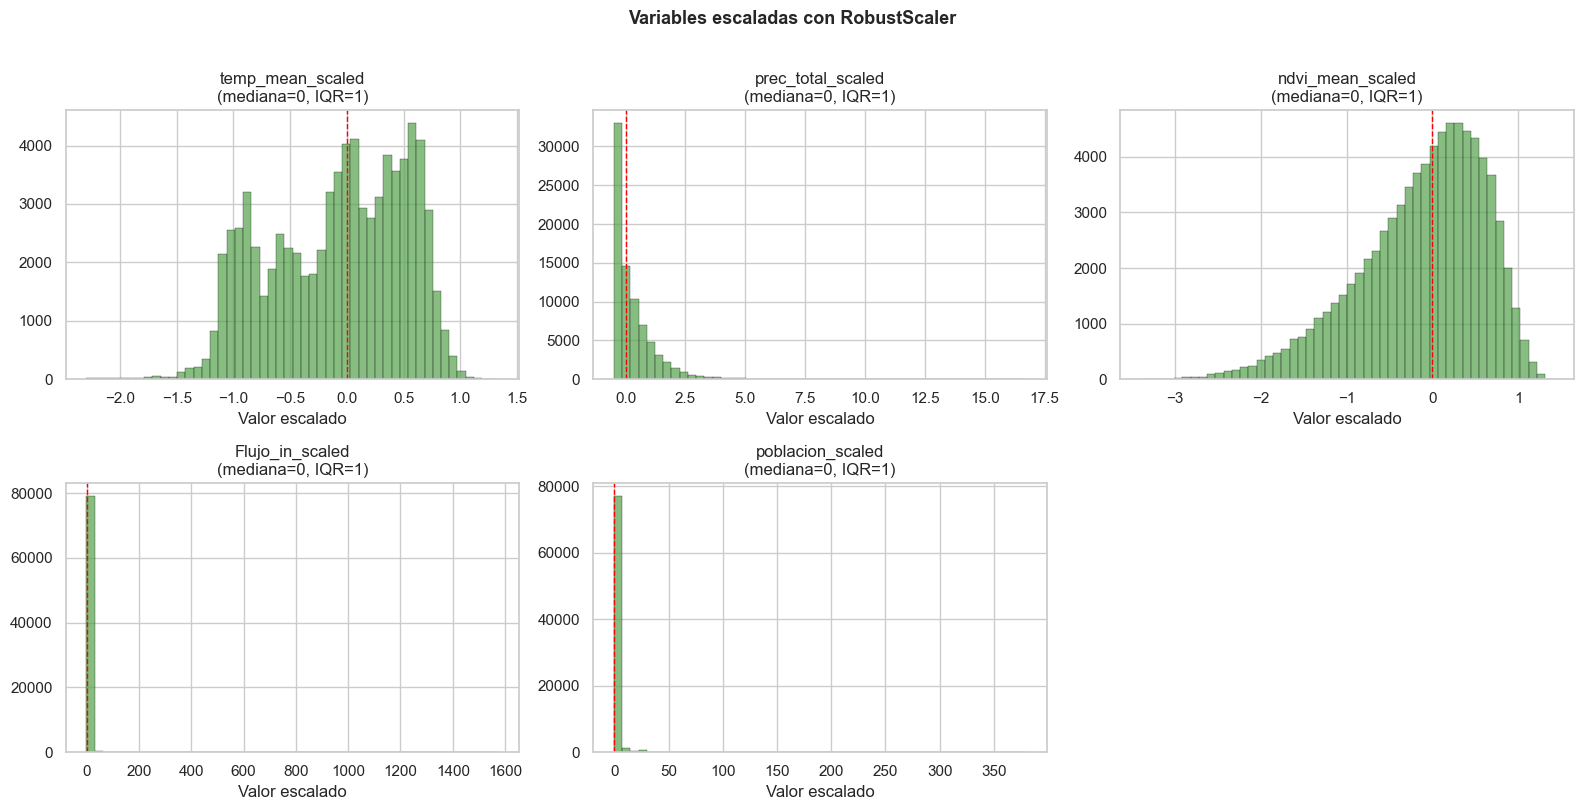

In [11]:
# Variables a escalar
scale_vars = ["temp_mean", "prec_total", "ndvi_mean", "Flujo_in", "poblacion"]

scaler = RobustScaler()
scaled_data = scaler.fit_transform(df[scale_vars])
scaled_df = pd.DataFrame(scaled_data, columns=[f"{v}_scaled" for v in scale_vars], index=df.index)

df = pd.concat([df, scaled_df], axis=1)

# Documentar parámetros del escalador
scale_params = pd.DataFrame({
    "Variable": scale_vars,
    "Mediana (center)": scaler.center_,
    "IQR (scale)": scaler.scale_,
})

display(Markdown("### Parámetros del RobustScaler"))
display(scale_params)
scale_params.to_csv(TABLES_PATH / "robust_scaler_params.csv", index=False, encoding="utf-8-sig")

# Visualización antes/después
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, var in enumerate(scale_vars):
    ax = axes[i]
    sample = df[f"{var}_scaled"].sample(n=min(80000, len(df)), random_state=RANDOM_STATE)
    ax.hist(sample, bins=50, color="#54A24B", alpha=0.7, edgecolor="black", linewidth=0.3)
    ax.axvline(0, color="red", linestyle="--", linewidth=1)
    ax.set_title(f"{var}_scaled\n(mediana=0, IQR=1)")
    ax.set_xlabel("Valor escalado")

axes[-1].set_visible(False)
fig.suptitle("Variables escaladas con RobustScaler", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(SCALING_PATH / "variables_escaladas.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Transformaciones

Se aplican transformaciones para reducir asimetría y crear variables interpretables:
- **log1p:** Para variables de conteo con colas pesadas (casos, Flujo_in, población).
- **Tasa por 100k:** Normaliza casos por denominador poblacional.
- **Indicador binario:** Separa ocurrencia de intensidad.
- **Codificación cíclica:** Semana epidemiológica sin discontinuidad.

In [12]:
# --- 5.1 Transformaciones logarítmicas ---
df["log1p_casos"] = np.log1p(df["casos_totales"])
df["log1p_flujo"] = np.log1p(df["Flujo_in"])
df["log_poblacion"] = np.log1p(df["poblacion"])

# --- 5.2 Tasa epidemiológica ---
df["tasa_100k"] = df["casos_totales"] / df["poblacion"] * 100_000

# --- 5.3 Indicador binario de presencia ---
df["caso_binario"] = (df["casos_totales"] > 0).astype(int)

# --- 5.4 Codificación cíclica de semana ---
df["sem_sin"] = np.sin(2 * np.pi * df["SEMANA"] / 52)
df["sem_cos"] = np.cos(2 * np.pi * df["SEMANA"] / 52)

# --- 5.5 Trimestre ---
df["trimestre"] = ((df["MES"] - 1) // 3) + 1

# Resumen
transform_summary = pd.DataFrame([
    ["casos_totales", "log1p_casos", "log(1+x)", f"{df['casos_totales'].skew():.1f}", f"{df['log1p_casos'].skew():.2f}"],
    ["Flujo_in", "log1p_flujo", "log(1+x)", f"{df['Flujo_in'].skew():.1f}", f"{df['log1p_flujo'].skew():.2f}"],
    ["poblacion", "log_poblacion", "log(1+x)", f"{df['poblacion'].skew():.1f}", f"{df['log_poblacion'].skew():.2f}"],
    ["casos_totales", "tasa_100k", "x / poblacion × 100k", "-", f"{df['tasa_100k'].skew():.2f}"],
    ["casos_totales", "caso_binario", "1{x > 0}", "-", "-"],
    ["SEMANA", "sem_sin, sem_cos", "sin/cos(2π×sem/52)", "-", "-"],
], columns=["Original", "Transformada", "Fórmula", "Skew original", "Skew transformada"])

display(Markdown("### Transformaciones aplicadas"))
display(transform_summary)
transform_summary.to_csv(TABLES_PATH / "transformations_applied.csv", index=False, encoding="utf-8-sig")

### Transformaciones aplicadas

,Original,Transformada,Fórmula,Skew original,Skew transformada
0,casos_totales,log1p_casos,log(1+x),33.4,3.03
1,Flujo_in,log1p_flujo,log(1+x),37.5,2.90
2,poblacion,log_poblacion,log(1+x),23.3,0.86
3,casos_totales,tasa_100k,x / poblacion × 100k,-,12.05
4,casos_totales,caso_binario,1{x > 0},-,-
5,SEMANA,"sem_sin, sem_cos",sin/cos(2π×sem/52),-,-


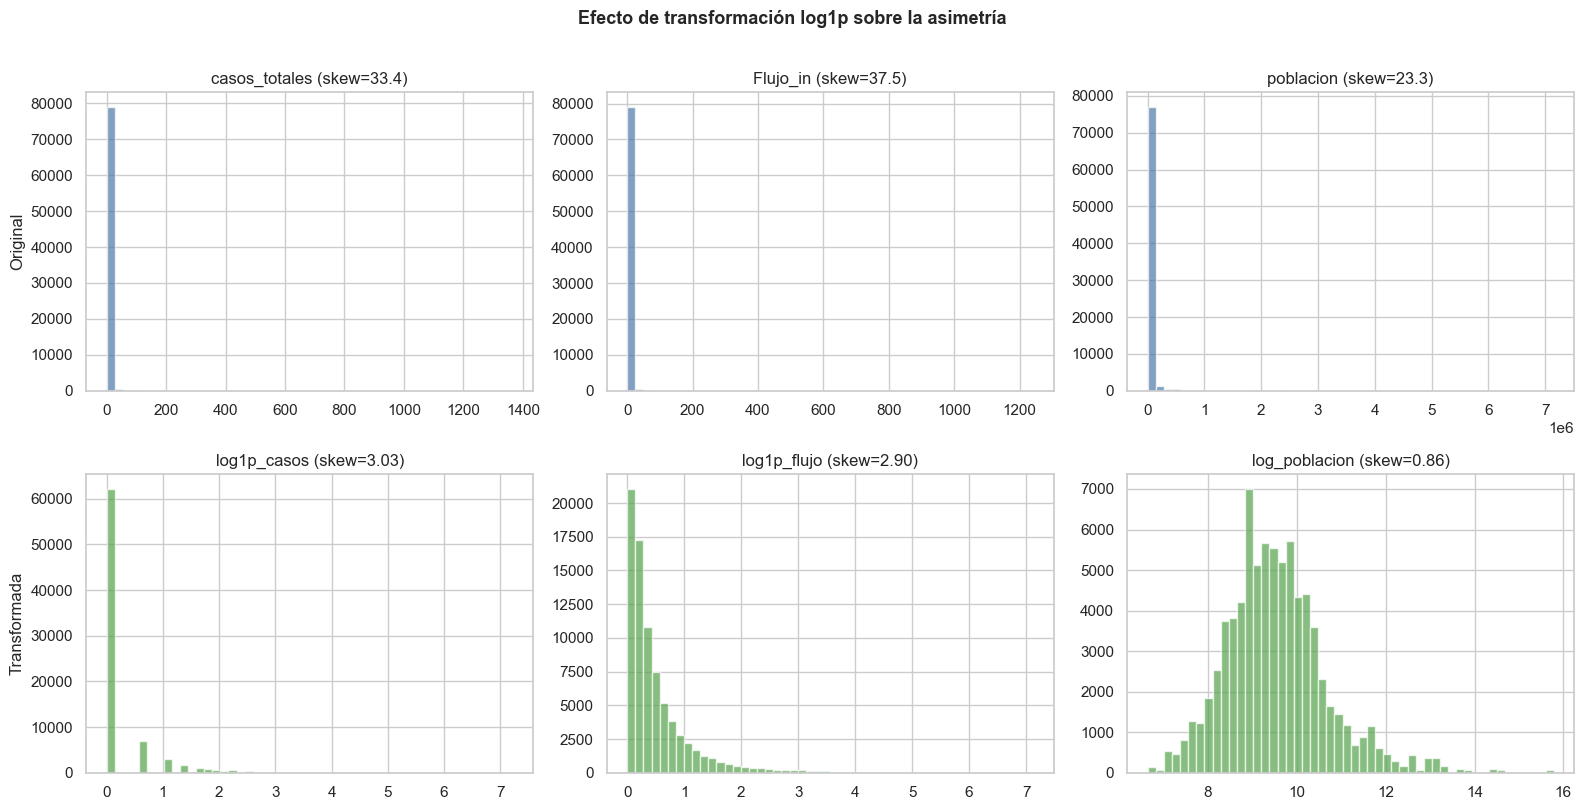

In [13]:
# Visualización de transformaciones
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

pairs = [
    ("casos_totales", "log1p_casos"),
    ("Flujo_in", "log1p_flujo"),
    ("poblacion", "log_poblacion"),
]

for i, (orig, trans) in enumerate(pairs):
    sample_orig = df[orig].sample(n=min(80000, len(df)), random_state=RANDOM_STATE)
    sample_trans = df[trans].sample(n=min(80000, len(df)), random_state=RANDOM_STATE)
    axes[0, i].hist(sample_orig, bins=50, color="#4C78A8", alpha=0.7)
    axes[0, i].set_title(f"{orig} (skew={df[orig].skew():.1f})")
    axes[1, i].hist(sample_trans, bins=50, color="#54A24B", alpha=0.7)
    axes[1, i].set_title(f"{trans} (skew={df[trans].skew():.2f})")

axes[0, 0].set_ylabel("Original")
axes[1, 0].set_ylabel("Transformada")
fig.suptitle("Efecto de transformación log1p sobre la asimetría", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(TRANSFORMS_PATH / "comparacion_log1p.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Variables Derivadas (Feature Engineering Temporal)

Se crean lags y promedios móviles que capturan la inercia epidémica. Estas variables son fundamentales porque la autocorrelación temporal domina la dinámica de dengue (notebook 02: DW=0.526).

In [14]:
# Ordenar por municipio y tiempo
df = df.sort_values(["COD_MUN_N", "ANO", "SEMANA"]).reset_index(drop=True)

# Crear time_idx (índice temporal secuencial por municipio)
df["time_idx"] = df.groupby("COD_MUN_N").cumcount()

# --- Lags epidemiológicos ---
for lag in [1, 2, 4]:
    df[f"casos_lag{lag}"] = df.groupby("COD_MUN_N")["casos_totales"].shift(lag)

# --- Promedios móviles ---
df["casos_roll4"] = (
    df.groupby("COD_MUN_N")["casos_totales"]
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).mean())
)

# --- Lags climáticos ---
df["prec_lag4"] = df.groupby("COD_MUN_N")["prec_total"].shift(4)
df["temp_lag4"] = df.groupby("COD_MUN_N")["temp_mean"].shift(4)

# --- Precipitación acumulada ---
df["prec_acum4"] = (
    df.groupby("COD_MUN_N")["prec_total"]
    .transform(lambda x: x.shift(1).rolling(4, min_periods=1).sum())
)

# --- ONI lag ---
df["oni_lag8"] = df.groupby("COD_MUN_N")["oni_anom"].shift(8)

# --- Fase ONI categórica ---
df["fase_oni"] = pd.cut(
    df["oni_anom"],
    bins=[-np.inf, -0.5, 0.5, np.inf],
    labels=["La Niña", "Neutro", "El Niño"],
)

# Reporte de features creadas
lag_cols = [c for c in df.columns if "lag" in c or "roll" in c or "acum" in c]
print("Variables derivadas creadas:")
for col in lag_cols:
    print(f"  {col}: {df[col].notna().sum():,} válidos ({df[col].notna().mean()*100:.1f}%)")

Variables derivadas creadas:
  casos_lag1: 812,240 válidos (99.9%)
  casos_lag2: 811,200 válidos (99.7%)
  casos_lag4: 809,120 válidos (99.5%)
  casos_roll4: 812,240 válidos (99.9%)
  prec_lag4: 808,328 válidos (99.4%)
  temp_lag4: 809,120 válidos (99.5%)
  prec_acum4: 811,456 válidos (99.8%)
  oni_lag8: 804,960 válidos (99.0%)


## 7. Manejo del Warm-up Period

Las operaciones de lag generan NaN en las primeras semanas de cada municipio. Se eliminan las primeras 8 semanas (warm-up) para garantizar completitud.

In [15]:
# Eliminar warm-up period
df_clean = df[df["time_idx"] >= 8].copy()

print(f"Antes del warm-up: {len(df):,} filas")
print(f"Después del warm-up: {len(df_clean):,} filas")
print(f"Eliminadas: {len(df) - len(df_clean):,} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# Verificar que no quedan NaN en variables de lag
lag_na = df_clean[lag_cols].isna().sum()
print(f"\nFaltantes en variables de lag después del warm-up:")
print(lag_na[lag_na > 0] if lag_na.sum() > 0 else "  Ninguno (0 NaN)")

Antes del warm-up: 813,280 filas
Después del warm-up: 804,960 filas
Eliminadas: 8,320 (1.02%)

Faltantes en variables de lag después del warm-up:
prec_lag4     788
prec_acum4    777
dtype: int64


## 8. Validación del Dataset Procesado

Se verifica la integridad lógica del dataset resultante antes de exportar.

In [16]:
validation_checks = []

# Check 1: Completitud
total_na = df_clean.select_dtypes(include=[np.number]).isna().sum().sum()
validation_checks.append({
    "Validación": "Completitud numérica (0 NaN en variables numéricas)",
    "Resultado": "PASA" if total_na == 0 else f"FALLA ({total_na} NaN)",
})

# Check 2: Panel balanceado
obs_per_mun = df_clean.groupby("COD_MUN_N").size()
balanced = obs_per_mun.nunique() == 1
validation_checks.append({
    "Validación": "Panel balanceado (mismas semanas por municipio)",
    "Resultado": f"PASA ({obs_per_mun.unique()[0]} sem/mun)" if balanced else "FALLA",
})

# Check 3: Consistencia log1p
log_ok = np.allclose(df_clean["log1p_casos"], np.log1p(df_clean["casos_totales"]))
validation_checks.append({
    "Validación": "Consistencia log1p_casos = log(1 + casos_totales)",
    "Resultado": "PASA" if log_ok else "FALLA",
})

# Check 4: Tasa consistente
tasa_ok = np.allclose(df_clean["tasa_100k"], df_clean["casos_totales"] / df_clean["poblacion"] * 100_000)
validation_checks.append({
    "Validación": "Consistencia tasa_100k",
    "Resultado": "PASA" if tasa_ok else "FALLA",
})

# Check 5: No negativos
non_neg_vars = ["casos_totales", "prec_total", "Flujo_in", "poblacion"]
has_neg = any((df_clean[v] < 0).any() for v in non_neg_vars)
validation_checks.append({
    "Validación": "No hay valores negativos en conteos/mediciones",
    "Resultado": "PASA" if not has_neg else "FALLA",
})

# Check 6: Escalado centrado en 0
scale_centered = all(abs(df_clean[f"{v}_scaled"].median()) < 0.01 for v in scale_vars)
validation_checks.append({
    "Validación": "Variables escaladas centradas en mediana ≈ 0",
    "Resultado": "PASA" if scale_centered else "FALLA",
})

validation_df = pd.DataFrame(validation_checks)
display(Markdown("### Validaciones de integridad"))
display(validation_df)
validation_df.to_csv(TABLES_PATH / "validation_checks.csv", index=False, encoding="utf-8-sig")

### Validaciones de integridad

,Validación,Resultado
0,Completitud numérica (0 NaN en variables numér...,FALLA (7011 NaN)
1,Panel balanceado (mismas semanas por municipio),PASA (774 sem/mun)
2,Consistencia log1p_casos = log(1 + casos_totales),PASA
3,Consistencia tasa_100k,PASA
4,No hay valores negativos en conteos/mediciones,PASA
5,Variables escaladas centradas en mediana ≈ 0,PASA


## 9. Exportación y Resumen del Dataset Procesado

In [17]:
# Selección de columnas para exportación
export_cols = [
    # Identificadores
    "COD_MUN_N", "depto", "ANO", "SEMANA", "MES", "week_start", "time_idx",
    # Epidemiológicas
    "casos_totales", "casos_0_4", "casos_5_14", "casos_15_64", "casos_65_plus",
    "casos_m", "casos_f",
    # Climáticas y ambientales (imputadas)
    "temp_mean", "prec_total", "ndvi_mean", "oni_anom", "oni_total",
    # Movilidad y demografía
    "Flujo_in", "poblacion",
    # Flags de imputación
    "temp_was_imputed", "prec_was_imputed",
    # Transformaciones
    "log1p_casos", "tasa_100k", "caso_binario", "log1p_flujo", "log_poblacion",
    # Escaladas
    "temp_mean_scaled", "prec_total_scaled", "ndvi_mean_scaled", "Flujo_in_scaled", "poblacion_scaled",
    # Features temporales
    "casos_lag1", "casos_lag2", "casos_lag4", "casos_roll4",
    "prec_lag4", "temp_lag4", "prec_acum4", "oni_lag8",
    # Estacionales
    "fase_oni", "trimestre", "sem_sin", "sem_cos",
]

df_export = df_clean[export_cols].copy()

# Exportar
output_path = Path("../data/processed")
output_path.mkdir(parents=True, exist_ok=True)
df_export.to_csv(output_path / "dataset_processed.csv", index=False, encoding="utf-8-sig")

print(f"Dataset exportado: {df_export.shape[0]:,} filas × {df_export.shape[1]} columnas")
print(f"Ruta: {output_path / 'dataset_processed.csv'}")
print(f"Municipios: {df_export['COD_MUN_N'].nunique()}")
print(f"Semanas por municipio: {df_export.groupby('COD_MUN_N').size().unique()[0]}")

Dataset exportado: 804,960 filas × 45 columnas
Ruta: ../data/processed/dataset_processed.csv
Municipios: 1040
Semanas por municipio: 774


In [18]:
# Tabla resumen de todo el preprocesamiento
decisions = pd.DataFrame([
    ["Filtrado", "Seleccionar municipios con 782 semanas completas", f"{df_export['COD_MUN_N'].nunique()} municipios retenidos de 1,040"],
    ["Imputación temp_mean", "Interpolación temporal + mediana departamental", f"{df_clean['temp_was_imputed'].sum():,} valores imputados ({df_clean['temp_was_imputed'].mean()*100:.1f}%)"],
    ["Imputación prec_total", "Interpolación temporal + mediana departamental", f"{df_clean['prec_was_imputed'].sum():,} valores imputados ({df_clean['prec_was_imputed'].mean()*100:.1f}%)"],
    ["Imputación ndvi/Flujo_in", "Forward/backward fill por municipio", "< 0.1% del dataset"],
    ["Escalamiento", "RobustScaler (mediana=0, IQR=1)", "5 variables: temp, prec, ndvi, Flujo_in, poblacion"],
    ["Transformación log1p", "log(1+x) para reducir asimetría", "casos (skew 33→~2), Flujo_in, poblacion"],
    ["Tasa por 100k", "Normalización por denominador poblacional", "Permite comparar municipios de distinto tamaño"],
    ["Codificación cíclica", "sin/cos de semana epidemiológica", "Captura estacionalidad sin discontinuidad sem 52→1"],
    ["Lags y rolling", "lag1,2,4; roll4; prec_lag4; temp_lag4; oni_lag8", "Capturan inercia epidémica y rezago biológico del vector"],
    ["Warm-up", "Eliminar primeras 8 semanas por municipio", f"{len(df)-len(df_clean):,} filas eliminadas ({(len(df)-len(df_clean))/len(df)*100:.1f}%)"],
], columns=["Paso", "Método", "Resultado"])

display(Markdown("### Resumen del pipeline de preprocesamiento"))
display(decisions)
decisions.to_csv(TABLES_PATH / "preprocessing_pipeline_summary.csv", index=False, encoding="utf-8-sig")

### Resumen del pipeline de preprocesamiento

,Paso,Método,Resultado
0,Filtrado,Seleccionar municipios con 782 semanas completas,"1040 municipios retenidos de 1,040"
1,Imputación temp_mean,Interpolación temporal + mediana departamental,"627,235 valores imputados (77.9%)"
2,Imputación prec_total,Interpolación temporal + mediana departamental,"278,441 valores imputados (34.6%)"
3,Imputación ndvi/Flujo_in,Forward/backward fill por municipio,< 0.1% del dataset
4,Escalamiento,"RobustScaler (mediana=0, IQR=1)","5 variables: temp, prec, ndvi, Flujo_in, pobla..."
5,Transformación log1p,log(1+x) para reducir asimetría,"casos (skew 33→~2), Flujo_in, poblacion"
6,Tasa por 100k,Normalización por denominador poblacional,Permite comparar municipios de distinto tamaño
7,Codificación cíclica,sin/cos de semana epidemiológica,Captura estacionalidad sin discontinuidad sem ...
8,Lags y rolling,"lag1,2,4; roll4; prec_lag4; temp_lag4; oni_lag8",Capturan inercia epidémica y rezago biológico ...
9,Warm-up,Eliminar primeras 8 semanas por municipio,"8,320 filas eliminadas (1.0%)"
